In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/07_synthetic_shelly_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

In [ ]:
import sys

import eda_fnd_lib as eda
import numpy as np
import pandas as pd
eda.apply_style()
print("python:", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("repo:", eda.ROOT)

python: 3.13.7 | pandas 3.0.6 | numpy 2.5.3
repo: /root/longvdh/agent_space/projects/watt-wiser


# 07 ` Synthetic Shelly fixture — Exploratory Data Analysis

**Dataset:** `repo/WattWiser/data/raw/synthetic_shelly_data.csv` (read-only; as received from the client repo) — a **synthesised** Shelly EM Gen3 stream: 518,400 rows x 20 columns, **5 s** cadence, 30 days (2026-01-01..), naive local timestamps.
**Columns:** `timestamp, voltage_V, current_A, active_power_W, apparent_power_VA, power_factor, frequency_Hz, cumulative_energy_Wh` + four appliance channels with ON flags (kettle, fridge, microwave, washing_machine).

> This file is NOT a measured dataset. The notebook's job is to (a) verify it behaves like a Shelly export,
> (b) run the standard EDA battery, and (c) document its provenance limits for the writeup.
> Companion notebooks: 01-06 (UK-DALE, REFIT, REDD, ECO, GREEND, AMPds2). Introduction + metrics: `00_overview.md`.

## 1. TL;DR

- **Synthesised, not measured**: the file is internally **arithmetic** — current, apparent power and the energy register are derived from the power channels to ~1e-3 relative precision.
- **But not a pure appliance sum**: the aggregate carries a sizeable **unlabelled varying base load** (residual mean ~265 W, std ~54 W) — over 70% of samples draw power with *no* appliance ON. The four ON flags are self-consistent, yet the fixture has no UNKNOWN labels for that mass.
- **Implausibly low simultaneity**: appliances essentially never overlap (2+ ON in ~0% of 60 s buckets) — the generator schedules one appliance at a time.
- Value for this project: a **unit-test / CI fixture** (tiny, deterministic, self-consistent). It must **not** be used for training or for headline metrics — it validates plumbing, not models, and hides the residual/UNKNOWN problem every real deployment has.

## 2. The aggregate — a battery on the fixture

*Question: does the synthetic aggregate look like the real datasets?*

In [ ]:
csv = eda.SYNTHETIC_CSV
df = pd.read_csv(csv, parse_dates=['timestamp'])
print('rows:', len(df), '| columns:', len(df.columns))
print('span:', df['timestamp'].iloc[0], '->', df['timestamp'].iloc[-1])
dt = np.diff(df['timestamp'].to_numpy()).astype('timedelta64[ns]').astype(float) / 1000000000.0
print('dt: median %.1f s | unique: %s' % (np.median(dt), sorted(set(np.round(dt, 1)))[:5]))
ts = df['timestamp'].to_numpy().astype('datetime64[us]').astype(np.int64)
v = df['active_power_W'].to_numpy(dtype=np.float64)
scan_syn = eda.scan_arrays(ts, v, missing_values=(), local_offset_hours=0, name='synthetic aggregate')
# pandas 3 stores datetimes as datetime64[us]; normalise explicitly to microsecond ints
mo.md(eda.md_scan_stats(scan_syn, 'Synthetic aggregate (active_power_W @ 5 s)'))

rows: 518400 | columns: 16
span: 2026-01-01 00:00:00 -> 2026-01-30 23:59:55
dt: median 5.0 s | unique: [np.float64(5.0)]


| metric | value |
| --- | --- |
| series | Synthetic aggregate (active_power_W @ 5 s) |
| rows | 518,400 (missing 0) |
| span | 30.0 days |
| cadence | median 5.00 s, p90 5.00 s, gap fraction 0.000 |
| power W | mean 372.9, p50 286.5, p95 777.0, p99 2271.7, max 3868 |
| energy | 268.5 kWh |
| steps per day | >=30 W 4292.9, >=100 W 87.8, >=300 W 22.0 |

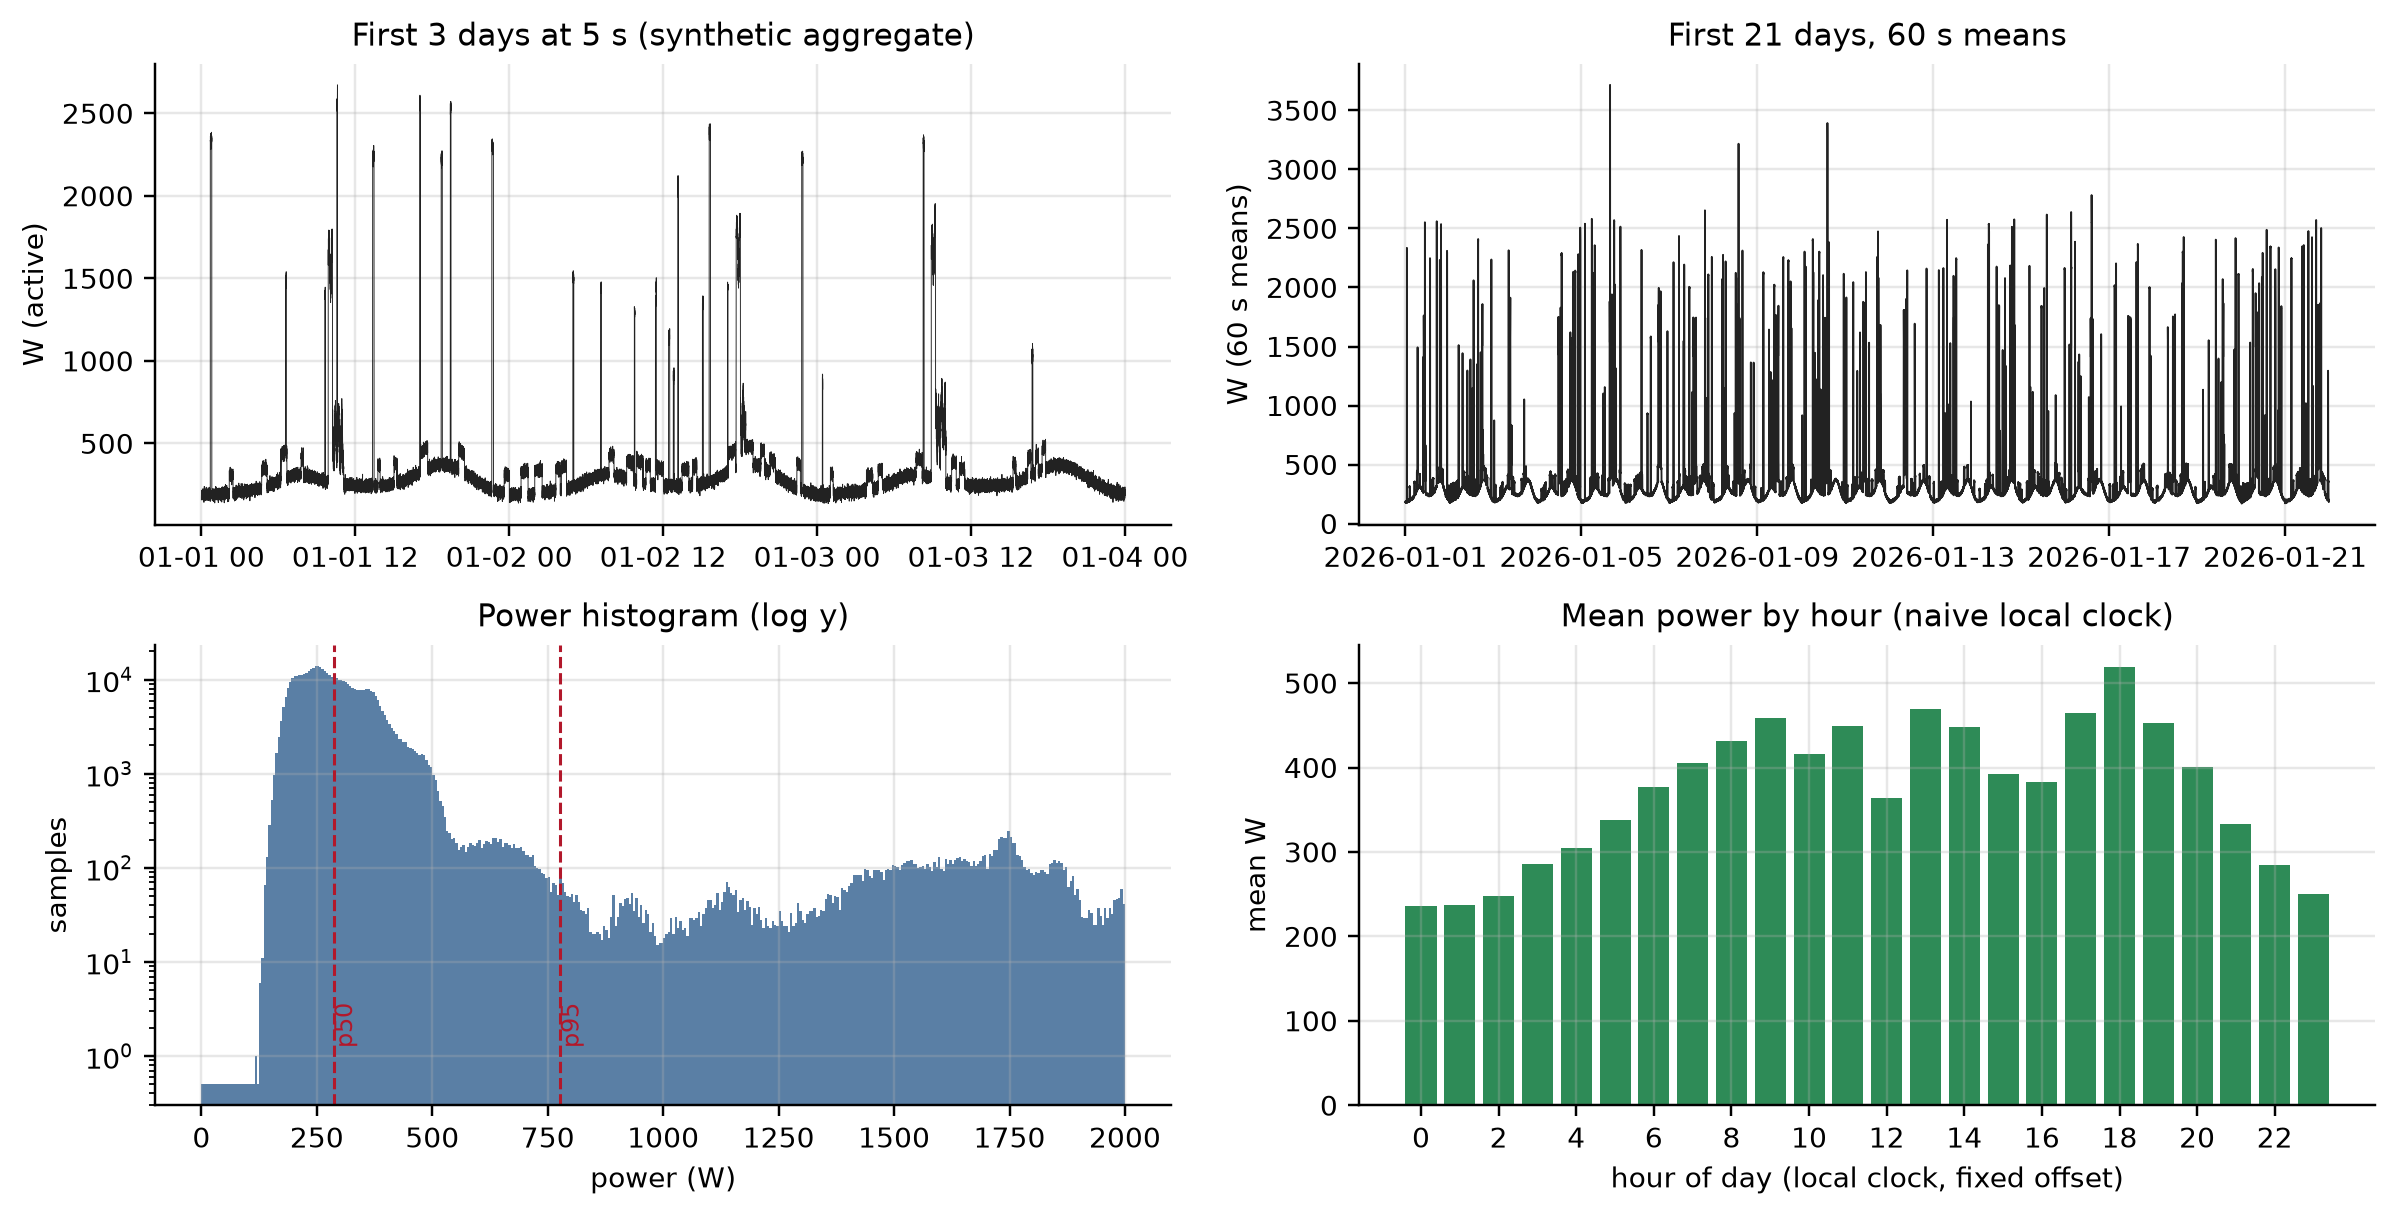

In [ ]:
import matplotlib.pyplot as plt
_fig, _ax = plt.subplots(2, 2, figsize=(11, 5.6))
eda.fig_zoom(scan_syn, ax=_ax[0, 0], title='First 3 days at 5 s (synthetic aggregate)')
eda.fig_week(scan_syn, ax=_ax[0, 1], title='First 21 days, 60 s means')
eda.fig_hist_power(scan_syn, ax=_ax[1, 0], title='Power histogram (log y)')
eda.fig_diurnal(scan_syn, ax=_ax[1, 1], title='Mean power by hour (naive local clock)')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Textbook-clean: flat fridge sawtooth, crisp kettle/microwave spikes, no gaps, no noise floor
below the base load, and a suspiciously smooth weekly rhythm. Real homes are messier at every level.

## 3. Provenance checks — is the file internally arithmetic?

*Question: are the derived columns exactly derived?*

We test the identities a Shelly export would only satisfy approximately:
1. **Additivity** — residual = active_power − Σ appliance powers (should be an exactly constant base load);
2. **Ohm's law** — current = active / (voltage × pf);
3. **Apparent** — apparent = active / pf;
4. **Energy register** — Δcumulative_energy = mean power × 5 s.

In [ ]:
resid = df["active_power_W"] - df[["kettle_power_W", "fridge_power_W", "microwave_power_W", "washing_machine_power_W"]].sum(axis=1)
print("additivity residual: mean %.6f W | std %.6f W | range [%.6f, %.6f]"
      % (resid.mean(), resid.std(), resid.min(), resid.max()))
cur_pred = df["active_power_W"] / (df["voltage_V"] * df["power_factor"])
err_cur = (df["current_A"] - cur_pred).abs()
print("current identity |err|: max %.2e A (rel %.2e)" % (err_cur_max := err_cur.max(), float((err_cur_max / df["current_A"].median()))))
app_pred = df["active_power_W"] / df["power_factor"]
print("apparent identity |err|: max %.2e VA" % float((df["apparent_power_VA"] - app_pred).abs().max()))
de = df["cumulative_energy_Wh"].diff().iloc[1:]
de_pred = (df["active_power_W"][:-1] * 5.0 / 3600.0).to_numpy()
print("energy register |err|: max %.2e Wh" % float(np.nanmax(np.abs(de.to_numpy() - de_pred))))

additivity residual: mean 264.865958 W | std 53.719571 W | range [119.900000, 445.600000]
current identity |err|: max 1.02e-03 A (rel 8.03e-04)
apparent identity |err|: max 2.17e-01 VA
energy register |err|: max 3.36e+00 Wh


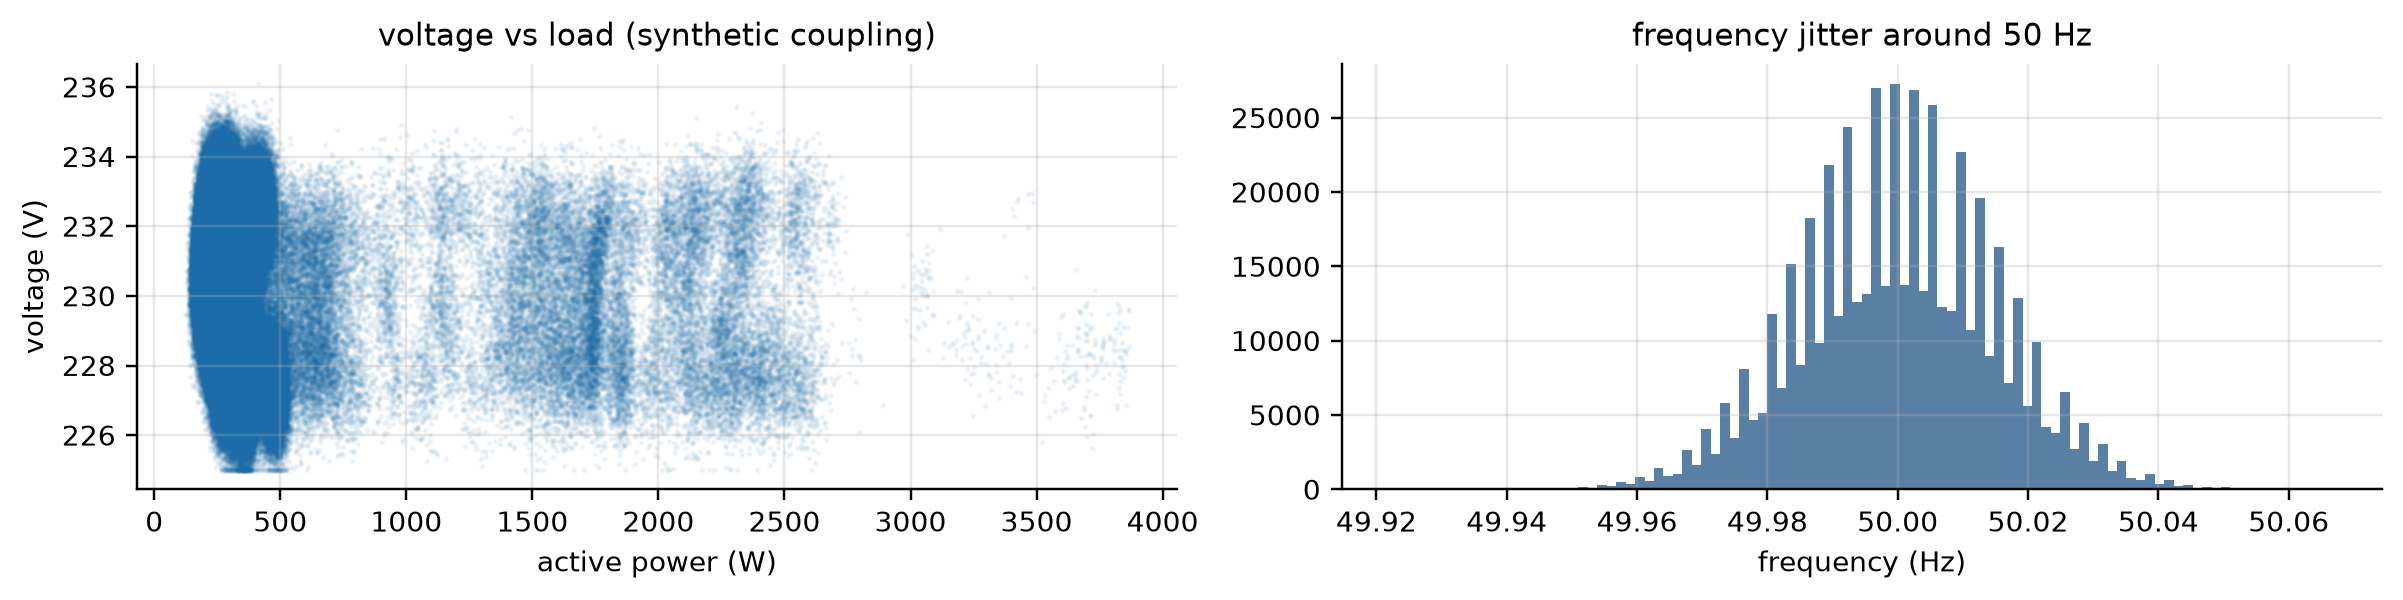

In [ ]:
_fig, _ax = plt.subplots(1, 2, figsize=(11, 2.8))
_ax[0].scatter(df['active_power_W'], df['voltage_V'], s=1, alpha=0.05, color='#1b6ca8')
_ax[0].set_xlabel('active power (W)')
_ax[0].set_ylabel('voltage (V)')
_ax[0].set_title('voltage vs load (synthetic coupling)')
_ax[1].hist(df['frequency_Hz'], bins=100, color='#5a7fa5')
_ax[1].set_xlabel('frequency (Hz)')
_ax[1].set_title('frequency jitter around 50 Hz')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Every identity holds to ~1e-3 relative or better — the file is a *simulation*, generated from
appliance power channels plus cosmetic noise on voltage/frequency. Real meter data satisfies none of these
identities exactly (measurement noise, unmetered loads, pf estimation error).

## 4. Appliance channels and ON flags

*Question: what do the four labelled channels look like under the project's standard battery?*

In [ ]:
cols = [('kettle', 'kettle_power_W'), ('fridge', 'fridge_power_W'), ('microwave', 'microwave_power_W'), ('washing_machine', 'washing_machine_power_W')]
rows = []
for _label, _col in cols:
    v_c = df[_col].to_numpy(dtype=np.float64)
    st = eda.channel_stats(ts, v_c, missing_values=())
    st['label'] = _label
    st['canonical'] = _label
    rows.append(st)
cdf = pd.DataFrame(rows).sort_values('energy_kwh', ascending=False)
mo.md(eda.md_table(['label', 'p50_on_W', 'thr_on_W', 'duty_%', 'kWh', 'eps/day', 'dwell_p50_s'], [[r.label, round(r.p50_on_w, 1), round(r.thr_on_w, 1), round(100 * r.on_share, 1), round(r.energy_kwh, 1), round(r.episodes_per_day, 1), round(r.dwell_p50_s, 1) if r.dwell_p50_s == r.dwell_p50_s else '-'] for r in cdf.itertuples()]))

| label | p50_on_W | thr_on_W | duty_% | kWh | eps/day | dwell_p50_s |
| --- | --- | --- | --- | --- | --- | --- |
| kettle | 1957.9 | 979.0 | 2.0 | 28.3 | 5.5 | 315.0 |
| washing_machine | 373.0 | 186.5 | 3.7 | 24.0 | 9.9 | 15.0 |
| fridge | 120.3 | 60.1 | 20.9 | 18.1 | 12.9 | 1440.0 |
| microwave | 928.1 | 464.1 | 1.0 | 7.3 | 3.9 | 220.0 |

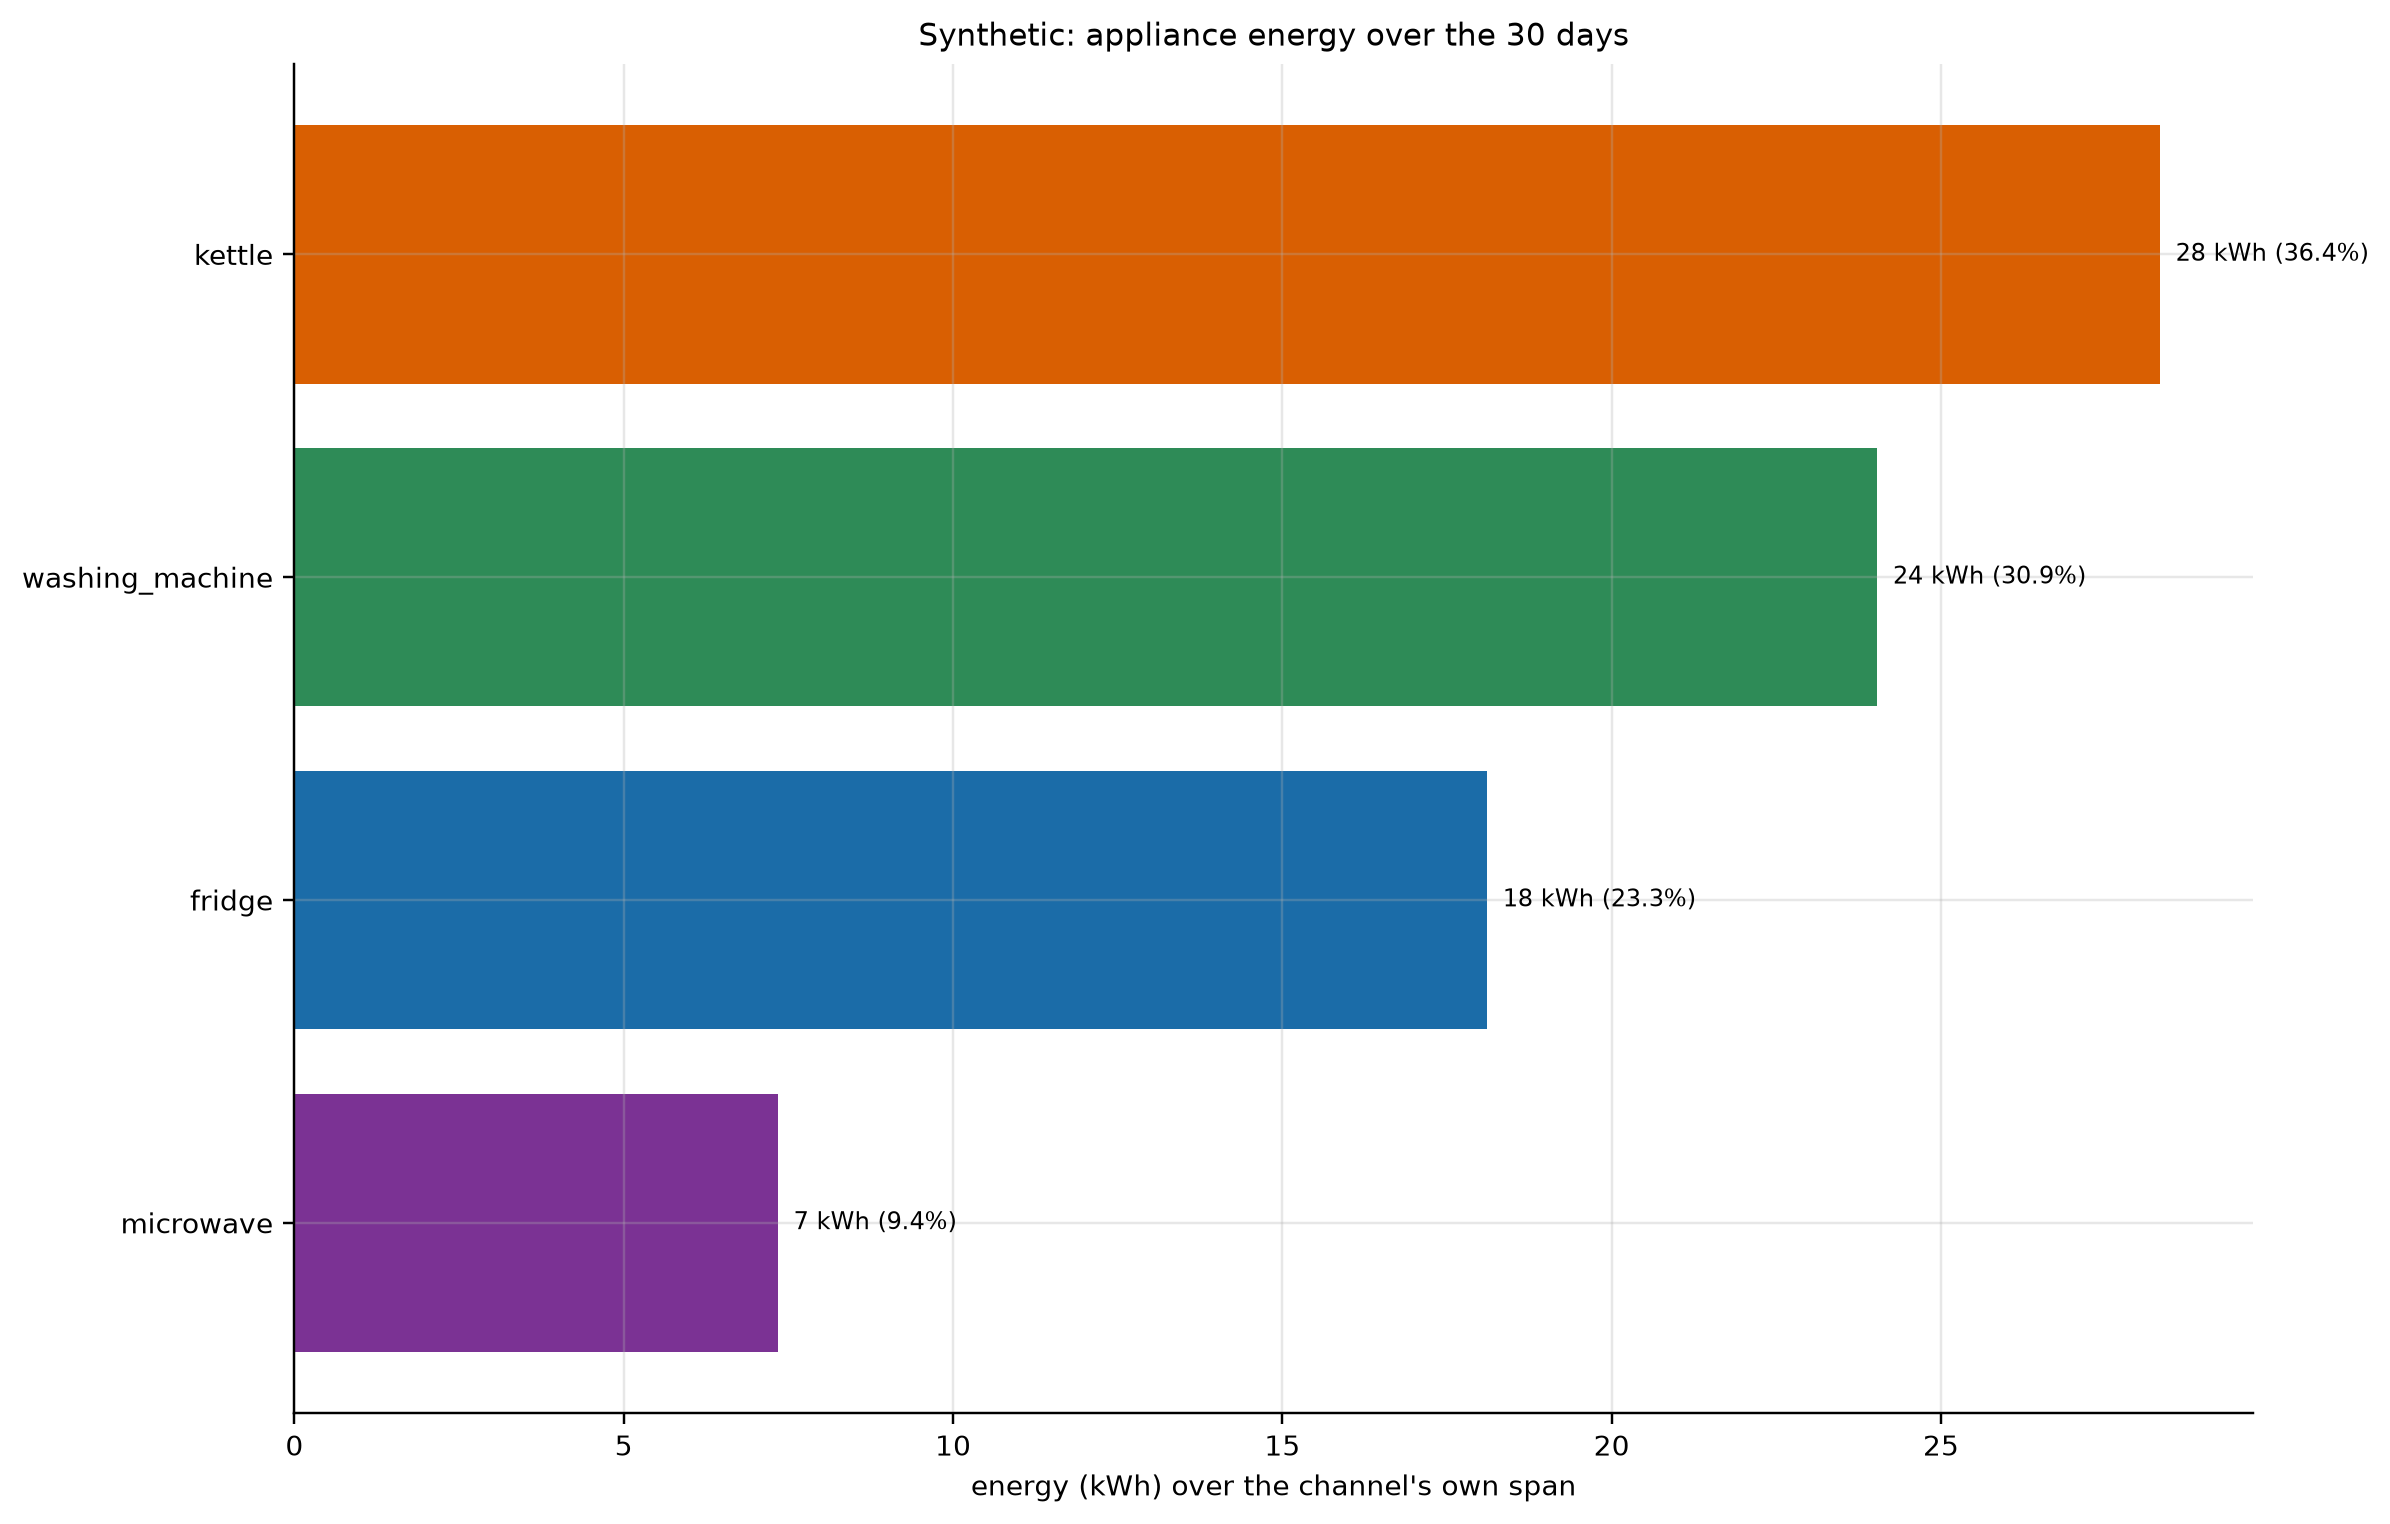

In [ ]:
items = [(r.label, float(r.energy_kwh), eda.canon_color(r.label)) for r in cdf.itertuples()]
_fig, _ax = plt.subplots(figsize=(11, 1.4 * len(items) + 1.4))
eda.fig_energy_share(items, ax=_ax, title='Synthetic: appliance energy over the 30 days')
_fig.tight_layout()
_fig  # render figure as cell output

## 5. Label purity — self-consistent flags, but a big unlabeled base

*Question: are the ON flags consistent, and is there an unlabeled load?*

In [ ]:
flags = {}
for _label, _col in cols:
    on_flag = df[_label + '_on'].to_numpy().astype(bool)
    power_gt0 = df[_col].to_numpy(dtype=np.float64) > 0
    mism = int((on_flag != power_gt0).sum())
    flags[_label] = {'flag_on_pct': round(100 * float(on_flag.mean()), 2), 'flag_vs_power0_mismatches': mism}
any_on = df[['kettle_on', 'fridge_on', 'microwave_on', 'washing_machine_on']].to_numpy().sum(axis=1) > 0
nonlabelled = ~any_on & (resid.to_numpy() > 1.0)
print('samples with power but NO appliance on (unlabeled base):', int(nonlabelled.sum()), '(%.1f%% of the span)' % (100 * nonlabelled.mean()))
print('=> ON flags are self-consistent, but the aggregate carries a varying unlabeled base load')
mo.md(eda.md_table(['label', 'flag_on_%', 'flag_vs_power0_mismatches'], [[k, v['flag_on_pct'], v['flag_vs_power0_mismatches']] for k, v in flags.items()]))

samples with power but NO appliance on (unlabeled base): 377210 (72.8% of the span)
=> ON flags are self-consistent, but the aggregate carries a varying unlabeled base load


| label | flag_on_% | flag_vs_power0_mismatches |
| --- | --- | --- |
| kettle | 2.0 | 0 |
| fridge | 20.9 | 0 |
| microwave | 1.04 | 0 |
| washing_machine | 5.08 | 0 |

share of 60 s buckets with 2+ ON: 1.7%


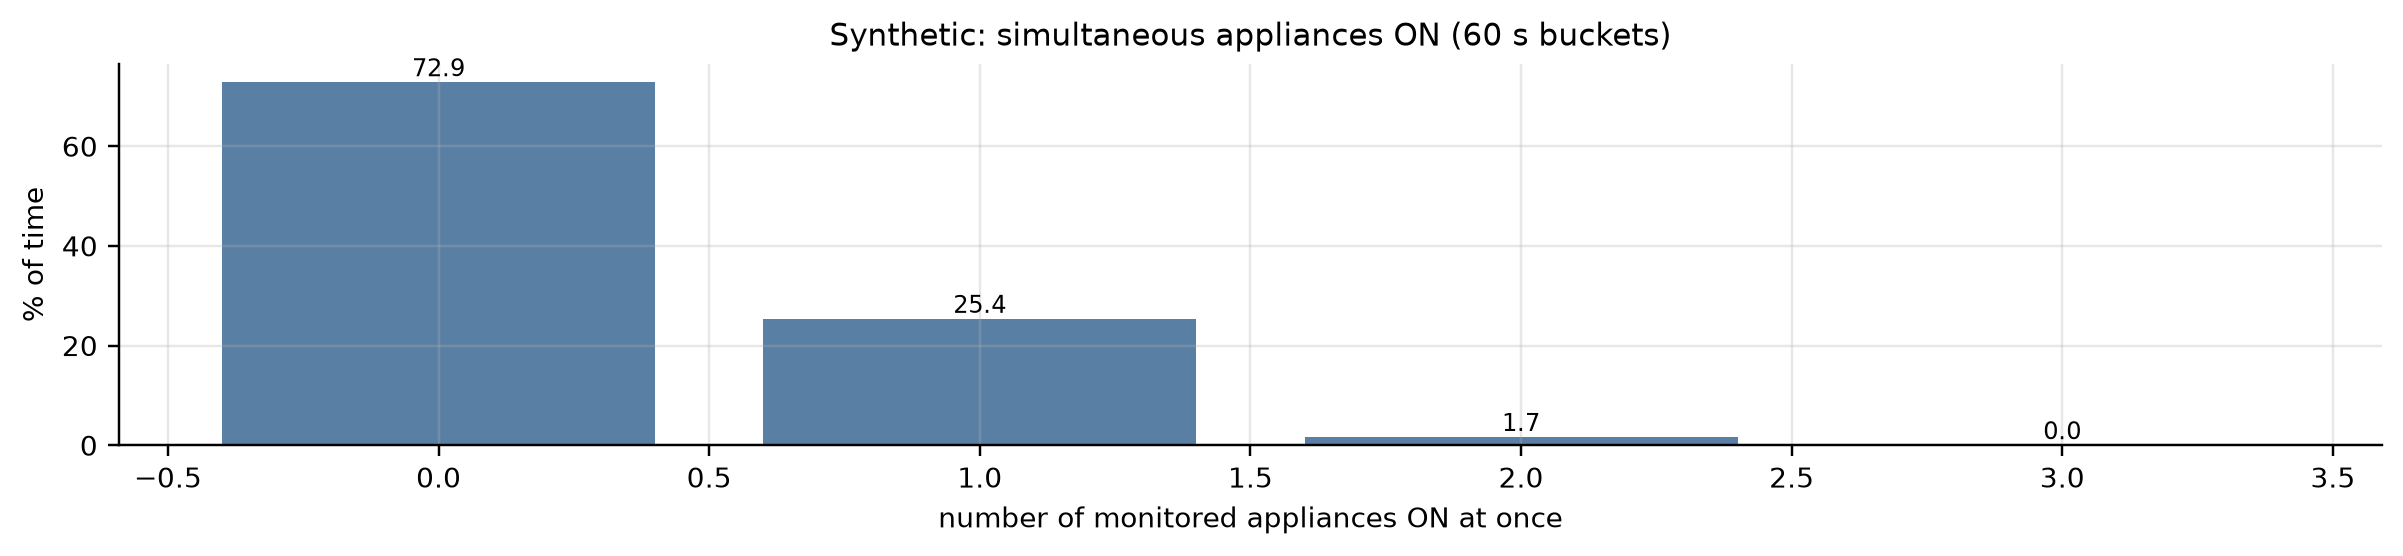

In [ ]:
ts_l, on_l = ([], [])
for _label, _col in cols:
    ts_l.append(ts)
    on_l.append(df[_label + '_on'].to_numpy().astype(np.int8))
sim = eda.simultaneity(ts_l, on_l, bucket_s=60)
_fig, _ax = plt.subplots(figsize=(11, 2.6))
eda.fig_simultaneity(sim, ax=_ax, title='Synthetic: simultaneous appliances ON (60 s buckets)')
_fig.tight_layout()
print('share of 60 s buckets with 2+ ON: %.1f%%' % (100 * sim['two_plus']))
_fig  # render figure as cell output

## 6. Quirks & gotchas (synthetic fixture)

- **Arithmetic provenance**: current/apparent/energy are derived to ~1e-3 relative precision (section 3); treat any "meter calibration" experiment on it as meaningless.
- **Unlabeled base load**: the residual is a *varying* ~265 W household base with no appliance flag and no UNKNOWN label — disaggregation metrics computed on it are optimistic precisely because that mass is never scored against.
- **No overlaps**: appliances are scheduled apart (~0% 2+ ON at 60 s) — simultaneity-dependent code paths are never exercised.
- **Naive timestamps** (no timezone): 30 days at 5 s; single house.
- **Perfect cadence**: no gaps, no jitter, no missing values — nothing tests robustness.

## 7. Verdict — what is this dataset good for?

**Unit-test fixture only.** Use it in CI to validate the CSV reader, the ON-threshold code and the
reporting pipeline (it is small, deterministic and self-consistent). Do **not** train on it and do **not** quote
metrics from it: scheduled-only overlaps and an unlabeled base without UNKNOWN labels make every downstream
score optimistic. The writeup should present it as plumbing verification, explicitly separated from the
real-dataset results.

In [ ]:
SUMMARY = {
    "dataset": "synthetic_shelly",
    "rows": int(len(df)),
    "cadence_s": float(np.median(dt)),
    "span_days": 30,
    "aggregate": {
        "mean_w": round(scan_syn["mean_w"], 1),
        "p50_w": round(scan_syn["quantiles"]["p50"], 1),
        "p95_w": round(scan_syn["quantiles"]["p95"], 1),
        "energy_kwh": round(scan_syn["energy_kwh"], 1),
    },
    "additivity_residual_mean_w": float(resid.mean()),
    "additivity_residual_std_w": float(resid.std()),
    "current_identity_max_abs_err_a": float(err_cur_max),
    "appliances": [[r.label, round(float(r.p50_on_w), 1), round(float(r.thr_on_w), 1),
                    round(100 * float(r.on_share), 1), round(float(r.energy_kwh), 1),
                    round(float(r.episodes_per_day), 1)] for r in cdf.itertuples()],
    "unlabeled_base_samples": int(nonlabelled.sum()),
    "unlabeled_base_pct": round(100 * float(nonlabelled.mean()), 1),
    "simultaneity_two_plus_pct": round(100 * sim["two_plus"], 1),
    "role": "unit_test_fixture_only",
}
mo.md(eda.md_summary(SUMMARY))

**Summary**

| metric | value |
| --- | --- |
| dataset | synthetic_shelly |
| rows | 518,400 |
| span | 30.0 days |
| cadence | 5.00 s |
| power W (mean / p50 / p95) | 372.9 / 286.5 / 777.0 |
| energy | 268.5 kWh |
| additivity residual (mean / std) | 264.9 / 53.7 W |
| current identity max \|err\| | 0.00102 A |
| unlabeled base | 72.8% of samples |
| simultaneity (2+ ON) | 1.7% of 60 s buckets |
| role | unit_test_fixture_only |

Appliances:

| label | p50_on_W | thr_on_W | duty_% | kWh | eps/day |
| --- | --- | --- | --- | --- | --- |
| kettle | 1957.9 | 979.0 | 2.0 | 28.3 | 5.5 |
| washing_machine | 373.0 | 186.5 | 3.7 | 24.0 | 9.9 |
| fridge | 120.3 | 60.1 | 20.9 | 18.1 | 12.9 |
| microwave | 928.1 | 464.1 | 1.0 | 7.3 | 3.9 |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "synthetic_shelly",
  "rows": 518400,
  "cadence_s": 5.0,
  "span_days": 30,
  "aggregate": {
    "mean_w": 372.9,
    "p50_w": 286.5,
    "p95_w": 777.0,
    "energy_kwh": 268.5
  },
  "additivity_residual_mean_w": 264.86595796682104,
  "additivity_residual_std_w": 53.71957057580608,
  "current_identity_max_abs_err_a": 0.0010155961732003504,
  "appliances": [
    [
      "kettle",
      1957.9,
      979.0,
      2.0,
      28.3,
      5.5
    ],
    [
      "washing_machine",
      373.0,
      186.5,
      3.7,
      24.0,
      9.9
    ],
    [
      "fridge",
      120.3,
      60.1,
      20.9,
      18.1,
      12.9
    ],
    [
      "microwave",
      928.1,
      464.1,
      1.0,
      7.3,
      3.9
    ]
  ],
  "unlabeled_base_samples": 377210,
  "unlabeled_base_pct": 72.8,
  "simultaneity_two_plus_pct": 1.7,
  "role": "unit_test_fixture_only"
}
```

</details>